## 0. 설정

In [1]:
<< mTensor`

In [2]:
$PreRead = 
  ReplaceAll[#, 
    expr_String :> StringReplace[expr,
    "TMP" -> "mTensor`Private"]] &;

In [3]:
DefineKind[Alphabet["Greek"], Greek];
DefineKind[ToUpperCase /@ Alphabet[], Capital];

## 1. Define Differential Forms

### 1.1 Fdefine

새로운 `IndexedObject`인 Diff. Form을 정의한다. 인자로는 form의 이름, 출력을 위한 문자열, degree, 문자열 형태의 permutation이 필요하다. 출력을 위한 문자열이 없으면 form의 이름이 출력을 위한 문자열로 사용된다. 또한, permutation이 없으면 index가 없는 form이 된다.

#### 1.1.1 zero rank

In [5]:
Fdefine[alpha, "\[Alpha]", 1]; alpha

alpha

In [6]:
Fdefine[alpha[], "\[Alpha]", 1]; alpha

alpha

In [7]:
TMP`defineForm[alpha, "\[Alpha]", 1, "", {DefaultKind}, {}]

In [8]:
{GetRank[alpha], GetSymmetry[alpha], TMP`getKindL[alpha], 
 TMP`getDnupL[alpha]}

{0, GenSet[], {Latin}, {}}

같은 degree를 갖는 여러 개의 form을 동시에 정의할 수 있다.

In [9]:
Fdefine[{A, B}, 1]; {A, B}

{A, B}

같은 degree를 갖지만 출력을 위한 문자열을 각각 지정하여 여러 개의 form을 동시에 정의할 수 있다.

In [10]:
Fdefine[{A, B}, {"\[Alpha]", "\[Beta]"}, 1]; {A, B}

{A, B}

출력을 위한 문자열과 degree를 각각 지정하여 여러 개의 form을 동시에 정의할 수 있다.

In [11]:
Fdefine[{A, B}, {1, 2}]; {A, B}

{A, B}

In [12]:
Fdefine[{A, B}, {"\[Alpha]", "\[Beta]"}, {1, 2}]; {A, B}

{A, B}

#### 1.1.2 non-zero rank

IndexedForm을 정의하려면 문자열로 된 permutation을 입력한다.

In [13]:
Fdefine[A, 1, "2"]; {A[la], A[lb, la], A[la, lb, lc]}

{A[la], A[lb, la], A[la, lb, lc]}

In [14]:
{GetRank[A], GetSymmetry[A], TMP`getKindL[A], TMP`getDnupL[A]}

{2, Nonsymmetric, {Latin}, {-1}}

In [15]:
Fdefine[A[la, ub], 1]; A[la, lb]

A[la, lb]

In [16]:
{GetRank[A], GetSymmetry[A], TMP`getKindL[A], TMP`getDnupL[A]}

{2, GenSet[], {Latin}, {-1, 1}}

In [17]:
Fdefine[A, "\[Alpha]", 1, "3+"]; A[lb, la, lc]

A[lb, la, lc]

In [18]:
{GetRank[A], GetSymmetry[A], TMP`getKindL[A], TMP`getDnupL[A]}

{3, Symmetric, {Latin}, {-1}}

In [19]:
Fdefine[A[la, lb, u\[Mu]], "\[Alpha]", 1]; A[la, lb, u\[Mu]]

A[la, lb, uμ]

In [20]:
{GetRank[A], GetSymmetry[A], TMP`getKindL[A], TMP`getDnupL[A]}

{3, GenSet[], {Latin, Latin, Greek}, {-1, -1, 1}}

In [21]:
Fdefine[A, "\[Alpha]", 1, "2-"]; A[lb, la]

A[lb, la]

In [22]:
{GetRank[A], GetSymmetry[A], TMP`getKindL[A], TMP`getDnupL[A]}

{2, Antisymmetric, {Latin}, {-1}}

In [23]:
Fdefine[A[la, lb], "\[Alpha]", 1, "2+"]; A[la, lb]

A[la, lb]

In [24]:
{GetRank[A], GetSymmetry[A], TMP`getKindL[A], TMP`getDnupL[A]}

{2, Symmetric, {Latin}, {-1}}

In [25]:
Fdefine[A, "\[Alpha]", 1, "*"]; A[lb]

A[lb]

In [26]:
{GetRank[A], GetSymmetry[A], TMP`getKindL[A], TMP`getDnupL[A]}

{-1, Nonsymmetric, {Latin}, {-1}}

In [27]:
Fdefine[A, "\[Alpha]", 1, "*-"]; A[lc, lb, la]

A[lc, lb, la]

In [28]:
{GetRank[A], GetSymmetry[A], TMP`getKindL[A], TMP`getDnupL[A]}

{-1, Antisymmetric, {Latin}, {-1}}

In [29]:
Fdefine[A, 1, "-ba"]; A[lb, la]

A[lb, la]

In [30]:
{GetRank[A], GetSymmetry[A], TMP`getKindL[A], TMP`getDnupL[A]}

{2, GenSet[{Cycles[{{1, 2}}], -1}], {Latin}, {-1}}

In [31]:
Fdefine[A[l\[Mu], l\[Nu]], 1, "-ba"]; A[l\[Nu], l\[Mu]]

A[lν, lμ]

In [32]:
{GetRank[A], GetSymmetry[A], TMP`getKindL[A], TMP`getDnupL[A]}

{2, GenSet[{Cycles[{{1, 2}}], -1}], {Greek}, {-1}}

In [33]:
Fdefine[{A, B}, 1, "ab"]; {A[la, ub], B[ua, lb]}

{A[la, ub], B[ua, lb]}

In [34]:
Fdefine[{A, B}, {"\[Alpha]", "\[Beta]"}, 1, "ab"];
{A[la, ub], B[ua, lb]}

{A[la, ub], B[ua, lb]}

In [36]:
Fdefine[{A, B}, {1, 2}, "ba"]; {A[lb, la], B[la, lb]}

{A[lb, la], B[la, lb]}

In [37]:
Fdefine[{A, B}, {"\[Alpha]", "\[Beta]"}, {1, 2}, "a"];
{A[la], B[ua]}

{A[la], B[ua]}

정의된 form은 `RemoveObject`으로 제거할 수 있다.

In [39]:
RemoveObject[A]

In [40]:
IndexedFormQ[A]

False

인덱스의 반대칭 Permutation 때문에 자동적으로 0이 될 수 있다.

In [41]:
Fdefine[\[CapitalOmega], 2, "-ba"]

In [42]:
\[CapitalOmega][la, ua]

Ω[la, ua]

In [43]:
% // ToCanonical

0

#### 1.1.3 Check

In [44]:
Fdefine[{A, B}, "\[Alpha]", 2]

`1` `2` `3` `4`: incompatible arguments: {A, B} and {Î±}

In [45]:
Fdefine[{A, B}, {"\[Alpha]", "\[Beta]"}, 2]

In [46]:
Fdefine[{A, B, CC}, {1, 2}]

`1` `2` `3` `4`: incompatible arguments: {A, B, CC} and {1, 2}

In [47]:
Fdefine[{A, B, CC}, {1, 2, 3}]

In [48]:
Fdefine[{A, B, CC}, {"\[Alpha]", "\[Beta]"}, {1, 2, 3}]

`1` `2` `3` `4`: different numbers of elements in lists {A, B, CC} {Î±, Î²} {1, 2, 3}

In [49]:
Fdefine[{A, B, CC}, {"\[Alpha]", "\[Beta]", "\[Gamma]"},
         {1, 2, 3}]

In [50]:
Fdefine[A[la], 1, ""]

`1` `2` `3` `4`: incompatible arguments: {la} and ""

In [51]:
Fdefine[A[la], 1, "a"]

### 1.2 IndexedFormQ

인자로 주어진 이름이 Fdefine으로 정의된 것인가를 판단하는 질의함수이다.

In [52]:
IndexedFormQ /@ {A, B}

{True, True}

## 2. Differential Form Operators

### 2.1 XP: Exterior Product

XP type의 exterior product 연산자이다.

In [53]:
Fdefine[{f, A, B, G}, {0, 1, 2, 3}]

Zero-form은 자동적으로 XP에서 제거되고, 또한 순서도 자동적으로 조정된다.

In [54]:
{XP[f, f], XP[f, A], XP[B, A], XP[A, A], XP[B, B]}

2
{f , A f, XP[A, B], 0, XP[B, B]}

Wedge로 입력할 수 있다.

In [55]:
{f \[Wedge] f, f \[Wedge] A, B \[Wedge] A,
 A \[Wedge] A, B \[Wedge] B}

2
{f , A f, XP[A, B], 0, XP[B, B]}

Dimension이 고려된다.

In [56]:
SetDimension[2]

In [57]:
{A \[Wedge] f, A \[Wedge] B}

{A f, 0}

In [58]:
ClearDimension[]  (* default *)

Indexed form도 마찬가지이다.

In [59]:
Fdefine[{f, A, B, G}, {0, 1, 2, 3}, "a"]

In [60]:
{f[la] \[Wedge] A[lb], B[la] \[Wedge] A[lb],
 A[lb] \[Wedge] A[la], B[la] \[Wedge] B[lb]}

{A[lb] f[la], XP[A[lb], B[la]], -XP[A[la], A[lb]], XP[B[la], B[lb]]}

Indexd form에 대한 자동적인 간단화는 이루어지지 않는다.

In [61]:
A[ua] \[Wedge] A[la]  (* may be zero or not *)

-XP[A[la], A[ua]]

In [62]:
SetDimension[2]

In [63]:
{A[la] \[Wedge] f[lb], A[lb] \[Wedge] B[la]}

{A[la] f[lb], 0}

In [64]:
(A[la] + f[la]) \[Wedge] B[ua]

B[ua] f[la]

In [65]:
ClearDimension[]  (* default *)

### 2.2 XD: Exterior Derivative

XD type의 exterior derivative 연산자이다.

In [66]:
Fdefine[{f, A, B, G}, {0, 1, 2, 3}]

선형 미분 연산자이다.

In [67]:
{XD[f], XD[-A], XD[a B]}

{XD[f[]], -XD[A[]], a XD[B[]] + XP[XD[a], B]}

Indexed form에 대해서도 마찬가지이다.

In [68]:
Fdefine[{f, A, B}, {0, 1, 2}, "a"]

In [69]:
{XD[f[la]], XD[-A[la]], XD[a B[la]]}

{XD[f[la]], -XD[A[la]], a XD[B[la]] + XP[XD[a], B[la]]}

In [70]:
XD[B[la] \[Wedge] A[ua]]

-XP[A[ua], XD[B[la]]] + XP[XD[A[ua]], B[la]]

In [71]:
XD[A[la] \[Wedge] A[ua]]  (* may be zero or not *)

-XP[A[la], XD[A[ua]]] + XP[A[ua], XD[A[la]]]

Power and Log:

In [72]:
XD[f^2]

2
XD[f ]

In [73]:
XD[Log[f]]

XD[Log[f]]

In [74]:
% // FullForm

XD[Log[f]]

In [75]:
XD[Tscalar[f]]

XD[f[]]

In [76]:
FullForm[%]

XD[f[]]

### 2.3 LD: Lie Derivative

텐서를 위한 LD 연산자는 form에 대해서도 동일하게 작용한다.

In [77]:
Tdefine[v, "a"]

In [78]:
Fdefine[{f, A, B}, {0, 1, 2}, "a"]

In [79]:
{LD[v, f[la]], LD[v, A[ua]], LD[v, B[1]]}

{LD[v, f[la]], LD[v, A[ua]], LD[v, B[1]]}

In [80]:
{LD[v, A[la] \[Wedge] B[lb]], LD[v, XD[A[la]]]}

{XP[A[la], LD[v, B[lb]]] + XP[LD[v, A[la]], B[lb]], LD[v, XD[A[la]]]}

선형 연산자이다.

In [81]:
SetAttributes[{c1, c2}, Constant]

In [82]:
LD[v, c1 XD[A[la]] + c2 B[la]]

c2 LD[v, B[la]] + c1 LD[v, XD[A[la]]]

#### LDtoXDRule

In [83]:
Tdefine[\[Xi][ua]]

In [84]:
Fdefine[\[Omega][ua], 2]

In [85]:
LD[\[Xi], \[Omega][ua]]

LD[ξ, ω[ua]]

In [86]:
% /. LDtoXDRule[]

IP[ξ, XD[ω[ua]]] + XD[IP[ξ, ω[ua]]]

### 2.4 IP: Interior Product

LD type의 interior product 연산자이다.

In [87]:
Tdefine[v, "a"];
Fdefine[{f, A, B, G}, {0, 1, 2, 3}]

In [89]:
IP[v, #] & /@ {f, A, B, G}

{IP[v, f], IP[v, A], IP[v, B], IP[v, G]}

In [90]:
{IP[v, IP[v, A]], IP[v, IP[v, B]], IP[v, IP[v, G]]}

{IP[v, IP[v, A]], 0, 0}

Zero-form은 자동적으로 IP에서 제거된다.

In [91]:
{IP[v, f], IP[v, f A]}

{IP[v, f], f IP[v, A]}

선형 연산자이다.

In [92]:
IP[v, a XD[A] + b B]

b IP[v, B] + a IP[v, XD[A[]]]

$$
  \iota_v \alpha \wedge \beta
  = (\iota_v \alpha) \wedge \beta
  + (-1)^p \alpha \wedge (\iota_v \beta)
$$

In [93]:
IP[v, #] & /@ {f \[Wedge] f, f \[Wedge] A,
               B \[Wedge] A, B \[Wedge] B}

2
{IP[v, f ], f IP[v, A], B IP[v, A] - XP[A, IP[v, B]], 2 XP[IP[v, B], B]}

### 2.5 HodgeStar

In [94]:
Tdefine[v, "a"]; Fdefine[f, 0]; Fdefine[{a, b}, {1, 2}]

In [95]:
Fdefine[{A, B}, 1, "a"];
Fdefine[\[Omega][ub], 2];
Fdefine[\[CapitalOmega][ua, ub], 2, "-ba"]

In [100]:
GetDimension[Latin] = n; GetSignature[Latin] = s;

In [98]:
HodgeStar /@ {f, a, b}

{HodgeStar[f], HodgeStar[a], HodgeStar[b]}

In [99]:
HodgeStar /@ {A[la], B[la],
               \[Omega][la, lb], \[CapitalOmega][la, lb]}

{HodgeStar[A[la]], HodgeStar[B[la]], HodgeStar[ω[la, lb]], HodgeStar[Ω[la, lb]]}

In [101]:
HodgeStar /@ 
 HodgeStar /@ {A[la], B[la],
                \[Omega][la, lb], \[CapitalOmega][la, lb]}

-1 + n + (n - s)/2            -1 + n + (n - s)/2         n - s
{(-1)                   A[la], (-1)                   B[la], I      ω[la, lb], 
 
        2 (-2 + n) + (n - s)/2
>   (-1)                       Ω[la, lb]}

In [102]:
DegreeForm /@ (HodgeStar /@ {A[la], B[la], \[Omega][la, lb],
                              \[CapitalOmega][la, lb]})

{-1 + n, -1 + n, n, -2 + n}

In [103]:
SetDimension[2]

In [104]:
ZeroDegreeQ /@ (HodgeStar /@ {A[la], B[la], \[Omega][la, lb],
                               \[CapitalOmega][la, lb]})

{False, False, False, True}

In [105]:
ClearDimension[]

In [106]:
ZeroDegreeQ /@ (HodgeStar /@ {A[la], B[la], \[Omega][la, lb],
                               \[CapitalOmega][la, lb]})

{False, False, False, False}

### 2.6 CoXD

In [107]:
Tdefine[v, "a"]; Fdefine[f, 0]; Fdefine[{a, b}, {1, 2}]

In [108]:
Fdefine[{A, B}, 1, "a"];
Fdefine[\[Omega][ub], 2];
Fdefine[\[CapitalOmega][ua, ub], 2, "-ba"]

In [111]:
GetDimension[Latin] = n; GetSignature[Latin] = s;

In [112]:
CoXD[\[Omega][ua]] /. CoXDRule[]

1 + n + (n - s)/2
(-1)                  HodgeStar[XD[HodgeStar[ω[ua]]]]

In [113]:
CoXD /@ {f, a, b}

{0, CoXD[a], CoXD[b]}

In [114]:
CoXD /@ {A[la], B[la], \[Omega][la], \[CapitalOmega][la, lb]}

{CoXD[A[la]], CoXD[B[la]], CoXD[ω[la]], CoXD[Ω[la, lb]]}

In [115]:
CoXD /@ CoXD /@ {A[la], B[la],
                  \[Omega][la], \[CapitalOmega][la, lb]}

{0, 0, 0, 0}

In [116]:
DegreeForm /@ (CoXD /@ {A[la], B[la], \[Omega][la],
                         \[CapitalOmega][la, lb]})

{0, 0, 1, 1}

In [117]:
ZeroDegreeQ /@ (CoXD /@ {A[la], B[la], \[Omega][la],
                          \[CapitalOmega][la, lb]})

{True, True, False, False}

## 3. Differential Form Operations

### 3.1 ApplyXD

2 m             XD[r]
{Sqrt[1 - ---] XD[t], -------------, r XD[θ], r Sin[θ] XD[ϕ]}
           r                   2 m
                      Sqrt[1 - ---]
                                r
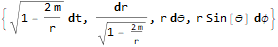

In [118]:
expr = {(1 - 2 m/r)^(1/2) XD[t], (1 - 2 m/r)^(-1/2) XD[r],
         r XD[\[Theta]], r Sin[\[Theta]] XD[\[Phi]]}

2 m                        1
{XP[XD[Sqrt[1 - ---]], XD[t]], XP[XD[-------------], XD[r]], XP[XD[r], XD[θ]], 
                 r                            2 m
                                     Sqrt[1 - ---]
                                               r
 
>   Sin[θ] XP[XD[r], XD[ϕ]] - r XP[XD[ϕ], XD[Sin[θ]]]}
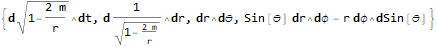

In [119]:
expr // ApplyXD

In [120]:
SetCoordinates[{t, r, \[Theta], \[Phi]}]

-2 BD[r, m]   2 m BD[r, r]
 -((----------- + ------------) XP[XD[t], XD[r]])
         r              2
                       r
{------------------------------------------------ - 
                            2 m
                 2 Sqrt[1 - ---]
                             r
 
      -2 BD[θ, m]   2 m BD[θ, r]
     (----------- + ------------) XP[XD[t], XD[θ]]
           r              2
                         r
>    --------------------------------------------- - 
                               2 m
                    2 Sqrt[1 - ---]
                                r
 
      -2 BD[ϕ, m]   2 m BD[ϕ, r]
     (----------- + ------------) XP[XD[t], XD[ϕ]]
           r              2
                         r
>    ---------------------------------------------, 
                               2 m
                    2 Sqrt[1 - ---]
                                r
 
     -2 BD[θ, m]   2 m BD[θ, r]
    (----------- + ------------) XP[XD[r], XD[θ]]
          r              2
                        r
>   --------------------------------------------- + 
                          2 m 3/2
                   2 (1 - ---)
                           r
 
      -2 BD[ϕ, m]   2 m BD[ϕ, r]
     (----------- + ------------) XP[XD[r], XD[ϕ]]
           r              2
                         r
>    --------------------------------------------- - 
                           2 m 3/2
                    2 (1 - ---)
                            r
 
      -2 BD[t, m]   2 m BD[t, r]
     (----------- + ------------) XP[XD[t], XD[r]]
           r              2
                         r
>    ---------------------------------------------, 
                           2 m 3/2
                    2 (1 - ---)
                            r
 
>   BD[r, r] XP[XD[r], XD[θ]] + BD[t, r] XP[XD[t], XD[θ]] - BD[ϕ, r] XP[XD[θ], XD[ϕ]], 
 
>   (r BD[r, θ] Cos[θ] + BD[r, r] Sin[θ]) XP[XD[r], XD[ϕ]] + 
 
>    (r BD[t, θ] Cos[θ] + BD[t, r] Sin[θ]) XP[XD[t], XD[ϕ]] + 
 
>    (r BD[θ, θ] Cos[θ] + BD[θ, r] Sin[θ]) XP[XD[θ], XD[ϕ]]}
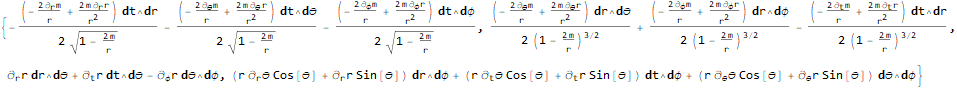

In [121]:
expr // ApplyXD

In [122]:
On[EvaluateBDFlag]

m XP[XD[t], XD[r]]
{-(------------------), 0, XP[XD[r], XD[θ]], 
             2 m   2
    Sqrt[1 - ---] r
              r
 
>   Sin[θ] XP[XD[r], XD[ϕ]] + r Cos[θ] XP[XD[θ], XD[ϕ]]}
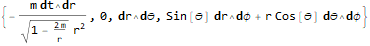

In [123]:
expr // ApplyXD

In [124]:
Off[EvaluateBDFlag]

In [125]:
ClearCoordinates[]

### 3.2 CollectForm

In [126]:
Tdefine[v[ua]];
Fdefine[{w1, w2}, {1, 2}]; Fdefine[x[ua], 0]

In [128]:
ToTensor[IP[v, XD[w1]], {la}] XD[x[ua]]

-(CD[la, w1[lb]] v[ub] XD[x[ua]]) + CD[lb, w1[la]] v[ub] XD[x[ua]]

CD[-2, w1[-1]] v[2] XD[x[1]] - CD[-1, w1[-2]] v[2] XD[x[1]] + 
 
>   CD[-3, w1[-1]] v[3] XD[x[1]] - CD[-1, w1[-3]] v[3] XD[x[1]] - 
 
>   CD[-2, w1[-1]] v[1] XD[x[2]] + CD[-1, w1[-2]] v[1] XD[x[2]] + 
 
>   CD[-3, w1[-2]] v[3] XD[x[2]] - CD[-2, w1[-3]] v[3] XD[x[2]] - 
 
>   CD[-3, w1[-1]] v[1] XD[x[3]] + CD[-1, w1[-3]] v[1] XD[x[3]] - 
 
>   CD[-3, w1[-2]] v[2] XD[x[3]] + CD[-2, w1[-3]] v[2] XD[x[3]]
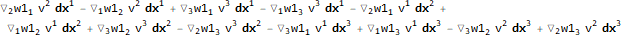

In [129]:
SumDum[{1, 3}, %]

In [130]:
CollectForm[%]

(CD[-2, w1[-1]] v[2] - CD[-1, w1[-2]] v[2] + CD[-3, w1[-1]] v[3] - CD[-1, w1[-3]] v[3]) 
 
>    XD[x[1]] + (-(CD[-2, w1[-1]] v[1]) + CD[-1, w1[-2]] v[1] + CD[-3, w1[-2]] v[3] - 
 
>      CD[-2, w1[-3]] v[3]) XD[x[2]] + 
 
>   (-(CD[-3, w1[-1]] v[1]) + CD[-1, w1[-3]] v[1] - CD[-3, w1[-2]] v[2] + 
 
>      CD[-2, w1[-3]] v[2]) XD[x[3]]

In [138]:
XP[w1, w2]

XP[w1, w2]

w1[lc] w2[la, lb] XP[XD[x[ua]], XD[x[ub]], XD[x[uc]]]
----------------------------------------------------- - 
                          6
 
    w1[lb] w2[la, lc] XP[XD[x[ua]], XD[x[ub]], XD[x[uc]]]
>   ----------------------------------------------------- + 
                              6
 
    w1[la] w2[lb, lc] XP[XD[x[ua]], XD[x[ub]], XD[x[uc]]]
>   -----------------------------------------------------
                              6
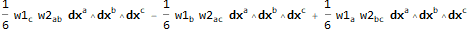

In [139]:
1/3! ToTensor[%, {la, lb, lc}
     ] XD[x[ua]] \[Wedge] XD[x[ub]] \[Wedge] XD[x[uc]]

In [140]:
SumDum[{1, 3}, %] // TindexSort

w1[-1] w2[-2, -3] XP[XD[x[1]], XD[x[2]], XD[x[3]]] - 
 
>   w1[-2] w2[-1, -3] XP[XD[x[1]], XD[x[2]], XD[x[3]]] + 
 
>   w1[-3] w2[-1, -2] XP[XD[x[1]], XD[x[2]], XD[x[3]]]

In [141]:
% // CollectForm

(w1[-1] w2[-2, -3] - w1[-2] w2[-1, -3] + w1[-3] w2[-1, -2]) 
 
>   XP[XD[x[1]], XD[x[2]], XD[x[3]]]

In [142]:
RemoveObject[x]

### 3.3 DegreeForm and ZeroDegreeQ

In [143]:
Fdefine[\[Omega][ua], 2]

In [144]:
{\[Omega][ua], \[Omega][lb, ua], \[Omega][lb, lc, ua]}

{ω[ua], ω[lb, ua], ω[lb, lc, ua]}

In [145]:
DegreeForm /@ %

{2, 0, 0}

In [146]:
ZeroDegreeQ /@ %%

{False, True, True}

### 3.4 ToTensor

In [147]:
Tdefine[f[]]; Tdefine[v[ua]]; Tdefine[T[la, lb]]

In [148]:
Fdefine[{w0, w1, w2, w3, w4}, {0, 1, 2, 3, 4}]

In [149]:
Fdefine[{A, B}, 1, "a"];
Fdefine[\[Omega][ua], 2];
Fdefine[\[CapitalOmega][ua, ub], 2, "-ba"]

In [152]:
{TMP`getGenSetOf[\[Omega][ub]],
 TMP`getGenSetOf[\[Omega][la, uc]], 
 TMP`getGenSetOf[\[Omega][la, lb, uc]]}

{GenSet[], GenSet[], GenSet[{Cycles[{{1, 2}}], -1}]}

In [153]:
{TMP`getGenSetOf[\[CapitalOmega][la, lb]], 
 TMP`getGenSetOf[\[CapitalOmega][la, lb, lc, ld]]}

{GenSet[{Cycles[{{1, 2}}], -1}], GenSet[{Cycles[{{1, 2}}], -1}, {Cycles[{{3, 4}}], -1}]}

In [154]:
TMP`checkObject[\[Omega], #, True] & /@ {{la}, {la, lb},
                                          {la, lb, lc},
                                          {la, lb, lc, ld}}

`1` `2` `3` `4`: invalid number of indices for Ï :  {la, lb}

`1` `2` `3` `4`: invalid number of indices for Ï :  {la, lb, lc, ld}

{True, False, True, False}

#### 3.4.1 p-form

In [155]:
ToTensor[f T[la, lb], {}]

f T[la, lb]

In [156]:
ToTensor[v[ua] T[lb, lc] w1, {ld}]

T[lb, lc] v[ua] w1[ld]

In [157]:
ToTensor[T[la, lb] w1[], {la}]

`1` `2` `3` `4`: invalid indices:  {la} for free indices {la, lb}

In [158]:
ToTensor[T[la, lb] w1, {ld}]

T[la, lb] w1[ld]

In [159]:
ToTensor[T[la, lb] \[Omega][uc], {lc, ld}]

`1` `2` `3` `4`: invalid indices:  {lc, ld} for free indices {la, lb, uc}

In [160]:
ToTensor[T[la, lb] \[Omega][uc], {ld, le}]

T[la, lb] ω[ld, le, uc]

In [161]:
ToTensor[T[la, lb] w1 w2, {lc}]

`1` `2` `3` `4`: invalid number of indices {lc} for w1 w2

In [162]:
ToTensor[T[la, lb] w1 w2, {lc, ud}]

`1` `2` `3` `4`: invalid number of indices {lc, ud} for w1 w2

In [163]:
ToTensor[T[la, lb] w1 w2, {ub, lc, ld}]

`1` `2` `3` `4`: invalid indices:  {ub, lc, ld} for free indices {la, lb}

In [164]:
ToTensor[T[la, lb] w1 w2, {lc, ld, ue}]

T[la, lb] w1[lc] w2[ld, ue]

In [165]:
ToTensor[\[Omega][ua], {lb, lc}]

ω[lb, lc, ua]

In [166]:
ToTensor[T[la, lb] w1 \[Omega][uc] w2, {ld, le, lf, lg, lh}]

T[la, lb] w1[ld] w2[le, lf] ω[lg, lh, uc]

In [167]:
ToTensor[\[CapitalOmega][ua, ub], {lc, ld}]

Ω[lc, ld, ua, ub]

#### 3.4.2 XD

In [168]:
ToTensor[XD[x], {la}]

CD[la, x]

In [169]:
ToTensor[XD[w1], {la, lb}]

CD[la, w1[lb]] - CD[lb, w1[la]]

In [170]:
ToTensor[T[la, lb] w1 XD[w1], {lc, ld, le}]

CD[ld, w1[le]] T[la, lb] w1[lc] - CD[le, w1[ld]] T[la, lb] w1[lc]

In [171]:
ToTensor[T[la, lb] w1 w2 XD[\[Omega][ua]],
          {la, lc, ld, le, lf, lg}]

CD[le, ω[lf, lg, uh]] T[lh, lb] w1[la] w2[lc, ld] - 
 
>   CD[lf, ω[le, lg, uh]] T[lh, lb] w1[la] w2[lc, ld] + 
 
>   CD[lg, ω[le, lf, uh]] T[lh, lb] w1[la] w2[lc, ld]

In [172]:
ToTensor[T[la, lb] w1 \[Omega][uc] XD[\[CapitalOmega][ua, ub]],
         {la, lb, ld, le, lf, lg}]

CD[lb, Ω[ld, le, uh, ui]] T[lh, li] w1[la] ω[lf, lg, uc] - 
 
>   CD[ld, Ω[lb, le, uh, ui]] T[lh, li] w1[la] ω[lf, lg, uc] + 
 
>   CD[le, Ω[lb, ld, uh, ui]] T[lh, li] w1[la] ω[lf, lg, uc]

#### 3.4.3 XP

In [173]:
ToTensor[XP[XD[x], XD[y]], {la, lb}]

-(CD[la, y] CD[lb, x]) + CD[la, x] CD[lb, y]

In [174]:
ToTensor[XP[w1, w2], {la, lb, lc}]

w1[lc] w2[la, lb] - w1[lb] w2[la, lc] + w1[la] w2[lb, lc]

In [175]:
ToTensor[T[la, lb] XP[w1, w2], {lc, ld, le}]

T[la, lb] w1[le] w2[lc, ld] - T[la, lb] w1[ld] w2[lc, le] + T[la, lb] w1[lc] w2[ld, le]

#### 3.4.4 LD

In [176]:
ToTensor[LD[v, w0], {}]

CD[la, w0] v[ua]

In [177]:
ToTensor[LD[v, w1], {la}]

LD[v, w1[la]]

In [178]:
ToTensor[LD[v, \[Omega][ua]], {lb, lc}]

LD[v, ω[lb, lc, ua]]

In [179]:
ToTensor[LD[v, \[CapitalOmega][ua, ub]], {lc, ld}]

LD[v, Ω[lc, ld, ua, ub]]

In [180]:
ToTensor[LD[v, w1 \[Wedge] w2], {la, lb, lc}]

LD[v, w2[lb, lc]] w1[la] - LD[v, w2[la, lc]] w1[lb] + LD[v, w2[la, lb]] w1[lc] + 
 
>   LD[v, w1[lc]] w2[la, lb] - LD[v, w1[lb]] w2[la, lc] + LD[v, w1[la]] w2[lb, lc]

In [181]:
ToTensor[LD[v, XD[x]], {la}]

LD[v, CD[la, x]]

#### 3.4.5 IP

In [182]:
ToTensor[IP[v, w1], {}]

v[ua] w1[la]

In [183]:
ToTensor[IP[v, XP[w1, w2]], {la, lb}]

v[uc] w1[lc] w2[la, lb] - v[uc] w1[lb] w2[la, lc] + v[uc] w1[la] w2[lb, lc]

In [184]:
ToTensor[IP[v, XD[w1]], {la}]

-(CD[la, w1[lb]] v[ub]) + CD[lb, w1[la]] v[ub]

In [185]:
ToTensor[IP[v, XP[XD[x], XD[y]]], {la}]

CD[la, y] CD[lb, x] v[ub] - CD[la, x] CD[lb, y] v[ub]

#### 3.4.6 HodgeStar

참고: R. M. Wald
\begin{gather*}
  \epsilon^{\mu_1 \cdots \mu_p \alpha_1 \cdots \alpha_{n-p}}
  \epsilon_{\mu_1 \cdots \mu_p \beta_1 \cdots \beta_{n-p}}
  = (-1)^s p! (n-p)!
  \delta_{\beta_1 \cdots \beta_{n-p}}
        ^{[\alpha_1 \cdots \alpha_{n-p}]} \\
  \alpha^*_{\beta_1 \cdots \beta_{n-p}} = \frac{1}{p!}
  \alpha^{\alpha_1 \cdots \alpha_p \beta_1 \cdots \beta_{n-p}} \\
  \alpha^{**} = (-1)^{s+p(n-p)} \alpha
\end{gather*}
where $s$ is the number of minuses, NOT the signature itself, appearing in the signature of $g_{ab}$. 

In [186]:
ToTensor[HodgeStar[XD[x]], {la}]

`1` `2` `3` `4`: Need to SetDimension[]   

In [187]:
SetDimension[3]; SetSignature[3]

In [188]:
ToTensor[HodgeStar[XD[x]], {la, lb}]

CD[lc, x] Epsilon[uc, la, lb]

In [189]:
ToTensor[HodgeStar[w1], {la, lb}]

Epsilon[uc, la, lb] w1[lc]

Epsilon[uc, ud, lb] ω[lc, ld, ua]
---------------------------------
                2
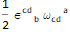

In [190]:
ToTensor[HodgeStar[\[Omega][ua]], {lb}]

-(CD[lb, y] CD[lc, x] Epsilon[ub, uc, la])   CD[lb, x] CD[lc, y] Epsilon[ub, uc, la]
------------------------------------------ + ---------------------------------------
                    2                                           2
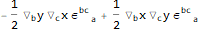

In [191]:
ToTensor[HodgeStar[XP[XD[x], XD[y]]], {la}]

Epsilon[ua, ud, ue] w1[le] Ω[la, ld, ub, uc]
-------------------------------------------- - 
                     6
 
    Epsilon[ua, ud, ue] w1[ld] Ω[la, le, ub, uc]
>   -------------------------------------------- + 
                         6
 
    Epsilon[ua, ud, ue] w1[la] Ω[ld, le, ub, uc]
>   --------------------------------------------
                         6
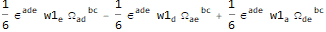

In [192]:
ToTensor[HodgeStar[XP[w1, \[CapitalOmega][ub, uc]]], {}]

-(Epsilon[la, ld, le] w1[ud] Ω[ua, ue, ub, uc])
-----------------------------------------------
                       2
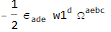

In [193]:
% // Tsimplify

In [194]:
ToTensor[HodgeStar[LD[\[Xi], XD[x]]], {la, lb}]

Epsilon[uc, la, lb] LD[ξ, CD[lc, x]]

Epsilon[ub, uc, ud] LD[ξ, CD[lb, ω[lc, ld, ua]]]
------------------------------------------------ - 
                       6
 
    Epsilon[ub, uc, ud] LD[ξ, CD[lc, ω[lb, ld, ua]]]
>   ------------------------------------------------ + 
                           6
 
    Epsilon[ub, uc, ud] LD[ξ, CD[ld, ω[lb, lc, ua]]]
>   ------------------------------------------------
                           6
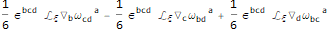

In [195]:
ToTensor[HodgeStar[LD[\[Xi], XD[\[Omega][ua]]]], {}]

-(Epsilon[ub, uc, ud] LD[ξ, CD[lc, ω[lb, ld, ua]]])
---------------------------------------------------
                         2
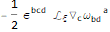

In [196]:
% // Tsimplify

In [197]:
ToTensor[HodgeStar[IP[\[Xi], XD[x]]], {la, lb, lc}]

CD[ld, x] Epsilon[la, lb, lc] ξ[ud]

In [198]:
ToTensor[HodgeStar[IP[\[Xi], XD[w1[]]]], {la, lb}]

CD[lc, w1[ld]] Epsilon[ud, la, lb] ξ[uc] - CD[lc, w1[ld]] Epsilon[uc, la, lb] ξ[ud]

CD[lc, ω[ld, le, ua]] Epsilon[ud, ue, lb] ξ[uc]
----------------------------------------------- + 
                       2
 
    CD[lc, ω[ld, le, ua]] Epsilon[uc, ud, lb] ξ[ue]
>   ----------------------------------------------- - 
                           2
 
    CD[lc, ω[ld, le, ua]] Epsilon[ud, uc, lb] ξ[ue]
>   -----------------------------------------------
                           2
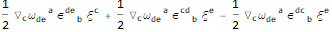

In [199]:
ToTensor[HodgeStar[IP[\[Xi], XD[\[Omega][ua]]]], {lb}]

CD[uc, ω[ud, ue, ua]] Epsilon[lb, ld, le] ξ[lc]
----------------------------------------------- - 
                       2
 
>   CD[uc, ω[ud, ue, ua]] Epsilon[lb, ld, lc] ξ[le]
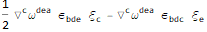

In [200]:
% // Tsimplify

CD[ld, Ω[le, lf, ua, ub]] Epsilon[ue, uf, lc] ξ[ud]
--------------------------------------------------- + 
                         2
 
    CD[ld, Ω[le, lf, ua, ub]] Epsilon[ud, ue, lc] ξ[uf]
>   --------------------------------------------------- - 
                             2
 
    CD[ld, Ω[le, lf, ua, ub]] Epsilon[ue, ud, lc] ξ[uf]
>   ---------------------------------------------------
                             2
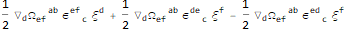

In [201]:
ToTensor[HodgeStar[IP[\[Xi], XD[\[CapitalOmega][ua, ub]]]], {lc}]

CD[ud, Ω[ue, uf, ua, ub]] Epsilon[lc, le, lf] ξ[ld]
--------------------------------------------------- - 
                         2
 
>   CD[ud, Ω[ue, uf, ua, ub]] Epsilon[lc, le, ld] ξ[lf]
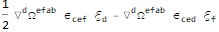

In [202]:
% // Tsimplify

In [203]:
ToTensor[HodgeStar[x], {la, lb, lc}]

x Epsilon[la, lb, lc]

In [204]:
CoXD[w1] /. CoXDRule[]

-HodgeStar[XD[HodgeStar[w1]]]

In [205]:
ToTensor[-HodgeStar[w1], {la, lb}]

-(Epsilon[uc, la, lb] w1[lc])

In [206]:
ToTensor[-XD[HodgeStar[w1]], {la, lb, lc}]

-(CD[lc, w1[ld]] Epsilon[la, lb, ud]) + CD[lb, w1[ld]] Epsilon[la, lc, ud] - 
 
>   CD[la, w1[ld]] Epsilon[lb, lc, ud]

-(CD[la, w1[lb]] Epsilon[lc, ld, ub] Epsilon[ua, uc, ud])
--------------------------------------------------------- + 
                            6
 
    CD[la, w1[lb]] Epsilon[lc, ld, ub] Epsilon[uc, ua, ud]
>   ------------------------------------------------------ - 
                              6
 
    CD[la, w1[lb]] Epsilon[lc, ld, ub] Epsilon[uc, ud, ua]
>   ------------------------------------------------------
                              6
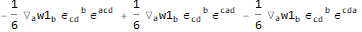

In [207]:
ToTensor[-HodgeStar[XD[HodgeStar[w1]]], {}]

In [208]:
% /. EpsilonProductRule[]

-(CD[la, w1[lb]] Metricg[ub, ua])

In [209]:
ClearDimension[]; ClearSignature[]

#### 3.4.7 CoXD

In [210]:
SetDimension[3]; SetSignature[3]

In [211]:
CoXD[w1] /. CoXDRule[]

-HodgeStar[XD[HodgeStar[w1]]]

-(CD[la, CD[lb, x]] Epsilon[lc, ld, ub] Epsilon[ua, uc, ud])
------------------------------------------------------------ + 
                             6
 
    CD[la, CD[lb, x]] Epsilon[lc, ld, ub] Epsilon[uc, ua, ud]
>   --------------------------------------------------------- - 
                                6
 
    CD[la, CD[lb, x]] Epsilon[lc, ld, ub] Epsilon[uc, ud, ua]
>   ---------------------------------------------------------
                                6
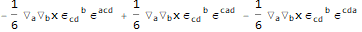

In [212]:
ToTensor[-HodgeStar[XD[HodgeStar[XD[x]]]], {}]

In [213]:
% /. EpsilonProductRule[]

-(CD[la, CD[lb, x]] Metricg[ub, ua])

In [214]:
% // Absorbg

-CD[ub, CD[lb, x]]

In [215]:
ToTensor[CoXD[XD[x]], {}]

-CD[ua, CD[la, x]]

-(CD[la, CD[lb, w0[]]] Epsilon[lc, ld, ub] Epsilon[ua, uc, ud])
--------------------------------------------------------------- + 
                               6
 
    CD[la, CD[lb, w0[]]] Epsilon[lc, ld, ub] Epsilon[uc, ua, ud]
>   ------------------------------------------------------------ - 
                                 6
 
    CD[la, CD[lb, w0[]]] Epsilon[lc, ld, ub] Epsilon[uc, ud, ua]
>   ------------------------------------------------------------
                                 6
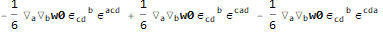

In [216]:
ToTensor[-HodgeStar[XD[HodgeStar[XD[w0]]]], {}]

In [217]:
% /. EpsilonProductRule[]

-(CD[la, CD[lb, w0[]]] Metricg[ub, ua])

In [218]:
% // Absorbg

-CD[ub, CD[lb, w0[]]]

In [219]:
ToTensor[CoXD[XD[w0]], {}]

-CD[ua, CD[la, w0[]]]

-(CD[la, w1[lb]] Epsilon[lc, ld, ub] Epsilon[ua, uc, ud])
--------------------------------------------------------- + 
                            6
 
    CD[la, w1[lb]] Epsilon[lc, ld, ub] Epsilon[uc, ua, ud]
>   ------------------------------------------------------ - 
                              6
 
    CD[la, w1[lb]] Epsilon[lc, ld, ub] Epsilon[uc, ud, ua]
>   ------------------------------------------------------
                              6
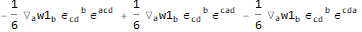

In [220]:
ToTensor[-HodgeStar[XD[HodgeStar[w1]]], {}]

In [221]:
% /. EpsilonProductRule[] // Absorbg

-CD[ub, w1[lb]]

In [222]:
ToTensor[CoXD[w1], {}]

-CD[ua, w1[la]]

In [223]:
CoXD[w2] /. CoXDRule[]

HodgeStar[XD[HodgeStar[w2]]]

CD[lb, w2[lc, ld]] Epsilon[le, uc, ud] Epsilon[ub, ue, la]
---------------------------------------------------------- - 
                            4
 
    CD[lb, w2[lc, ld]] Epsilon[le, uc, ud] Epsilon[ue, ub, la]
>   ----------------------------------------------------------
                                4
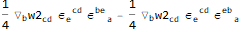

In [224]:
ToTensor[HodgeStar[XD[HodgeStar[w2]]], {la}]

In [225]:
% /. EpsilonProductRule[] // Absorbg // Tsimplify

CD[lb, w2[la, ub]]

In [226]:
ToTensor[CoXD[w2], {la}]

-CD[ub, w2[lb, la]]

In [227]:
CoXD[w3] /. CoXDRule[]

-HodgeStar[XD[HodgeStar[w3]]]

-(CD[lc, w3[ld, le, lf]] Epsilon[uc, la, lb] Epsilon[ud, ue, uf])
-----------------------------------------------------------------
                                6
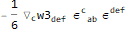

In [228]:
ToTensor[-HodgeStar[XD[HodgeStar[w3]]], {la, lb}]

In [229]:
% /. EpsilonProductRule[] // Absorbg // Tsimplify

-CD[lc, w3[la, lb, uc]]

In [230]:
ToTensor[CoXD[w3], {la, lb}]

-CD[uc, w3[lc, la, lb]]

In [231]:
ToTensor[CoXD[XD[w0]], {}]

-CD[ua, CD[la, w0[]]]

In [232]:
ToTensor[XD[CoXD[w0]], {}]

0

In [233]:
ToTensor[CoXD[XD[w2]], {la, lb}]

-CD[uc, CD[la, w2[lb, lc]]] + CD[uc, CD[lb, w2[la, lc]]] - CD[uc, CD[lc, w2[la, lb]]]

In [234]:
ToTensor[CoXD[\[Omega][ua]], {lb}]

-CD[uc, ω[lc, lb, ua]]

In [235]:
ToTensor[CoXD[XP[XD[x], XD[y]]], {la}]

CD[lb, y] CD[ub, CD[la, x]] - CD[lb, x] CD[ub, CD[la, y]] - 
 
>   CD[la, y] CD[ub, CD[lb, x]] + CD[la, x] CD[ub, CD[lb, y]]

In [236]:
ToTensor[CoXD[XP[w1, \[CapitalOmega][ub, uc]]], {la, ld}]

-(CD[ue, Ω[ld, le, ub, uc]] w1[la]) + CD[ue, Ω[la, le, ub, uc]] w1[ld] - 
 
>   CD[ue, Ω[la, ld, ub, uc]] w1[le] - CD[ue, w1[le]] Ω[la, ld, ub, uc] + 
 
>   CD[ue, w1[ld]] Ω[la, le, ub, uc] - CD[ue, w1[la]] Ω[ld, le, ub, uc]

In [237]:
ToTensor[CoXD[LD[\[Xi], XD[x]]], {}]

-CD[ua, LD[ξ, CD[la, x]]]

In [238]:
ToTensor[CoXD[LD[\[Xi], XD[\[Omega][ua]]]], {lb, lc}]

-CD[ud, LD[ξ, CD[lb, ω[lc, ld, ua]]]] + CD[ud, LD[ξ, CD[lc, ω[lb, ld, ua]]]] - 
 
>   CD[ud, LD[ξ, CD[ld, ω[lb, lc, ua]]]]

In [239]:
ToTensor[CoXD[IP[\[Xi], XD[x]]], {}]

0

In [240]:
ToTensor[CoXD[IP[\[Xi], XD[w1]]], {}]

CD[la, w1[lb]] CD[ua, ξ[ub]] - CD[la, w1[lb]] CD[ub, ξ[ua]] + 
 
>   CD[ua, CD[la, w1[lb]]] ξ[ub] - CD[ua, CD[lb, w1[la]]] ξ[ub]

In [241]:
ToTensor[CoXD[IP[\[Xi], XD[\[Omega][ua]]]], {lb}]

CD[lb, ω[lc, ld, ua]] CD[uc, ξ[ud]] - CD[lc, ω[lb, ld, ua]] CD[uc, ξ[ud]] + 
 
>   CD[lc, ω[lb, ld, ua]] CD[ud, ξ[uc]] + CD[uc, CD[lb, ω[lc, ld, ua]]] ξ[ud] - 
 
>   CD[uc, CD[lc, ω[lb, ld, ua]]] ξ[ud] + CD[uc, CD[ld, ω[lb, lc, ua]]] ξ[ud]

In [242]:
ToTensor[CoXD[IP[\[Xi], XD[\[CapitalOmega][ua, ub]]]], {lc}]

CD[lc, Ω[ld, le, ua, ub]] CD[ud, ξ[ue]] - CD[ld, Ω[lc, le, ua, ub]] CD[ud, ξ[ue]] + 
 
>   CD[ld, Ω[lc, le, ua, ub]] CD[ue, ξ[ud]] + CD[ud, CD[lc, Ω[ld, le, ua, ub]]] ξ[ue] - 
 
>   CD[ud, CD[ld, Ω[lc, le, ua, ub]]] ξ[ue] + CD[ud, CD[le, Ω[lc, ld, ua, ub]]] ξ[ue]

### 3.5 Coordinate Representation

In [243]:
SetDimension[3]; Fdefine[x[ua], 0]

In [244]:
\[Omega][ua]

ω[ua]

XP[XD[x[ub]], XD[x[uc]]] ω[lb, lc, ua]
--------------------------------------
                  2
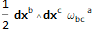

In [245]:
1/DegreeForm[\[Omega][ua]] ToTensor[\[Omega][ua], {lb, lc}] XP[
  XD[x[ub]], XD[x[uc]]]

-(XP[XD[x[2]], XD[x[3]]] ω[-3, -2, ua])   XP[XD[x[1]], XD[x[3]]] ω[-3, -1, ua]
--------------------------------------- - ------------------------------------ + 
                   2                                       2
 
    XP[XD[x[2]], XD[x[3]]] ω[-2, -3, ua]   XP[XD[x[1]], XD[x[2]]] ω[-2, -1, ua]
>   ------------------------------------ - ------------------------------------ + 
                     2                                      2
 
    XP[XD[x[1]], XD[x[3]]] ω[-1, -3, ua]   XP[XD[x[1]], XD[x[2]]] ω[-1, -2, ua]
>   ------------------------------------ + ------------------------------------
                     2                                      2
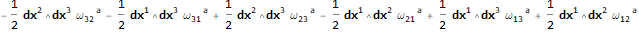

In [246]:
SumDum[%]

In [247]:
% // TindexSort

XP[XD[x[2]], XD[x[3]]] ω[-2, -3, ua] + XP[XD[x[1]], XD[x[3]]] ω[-1, -3, ua] + 
 
>   XP[XD[x[1]], XD[x[2]]] ω[-1, -2, ua]